# Multi-Stage Training on Synthetic Traces

Synthetic analogue of `training_multistage`: instead of experimental recordings, the
target voltage traces are generated from **known** AdEx ground-truth parameters, then
recovered with a staged curriculum. Because the true parameters are known,
every stage can be scored against ground truth — isolating the training pipeline from
experimental noise (cf. `training_synthetic_singlestage_*`).

The curriculum fits parameters in groups, each stage starting from the parameters fit in
the previous one:

**Subthreshold regime (MSE loss, subthreshold synthetic trace):**
1. **Stage 1 (MSE)**: coarsely match `C_m`, `E_L`
2. **Stage 2 (MSE)**: refine `E_L`, `g_L`

**Spiking regime (Guarino feature loss, spiking synthetic traces):**
3. **Stage 3 (Guarino)**: spike initiation — `v_T`, `delta_T`, `v_reset`
4. **Stage 4 (Guarino)**: adaptation — `tau_w`, `a`, `b`

**Temporal-alignment polish (Soft-DTW loss, spiking synthetic trace):**
5. **Stage 5 (Soft-DTW)**: refine all parameters under optimal temporal alignment

The Guarino feature-based loss (soft spike count, spike times, ISIs, firing rate,
subthreshold voltage) is used in the spiking stages because the AdEx reset removes spike
peaks, making raw-voltage MSE a poor signal once the neuron fires. The final soft-DTW
stage compares the full preprocessed voltage trace under an optimal time warp, providing
a smooth timing-aware gradient to polish spike timing.

## Prerequisits

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config
from jax.scipy.special import logsumexp

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley, simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_guarino_loss_fn,
    make_ttfs_rate_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
    TTFSRateLossConfig,
    make_van_rossum_loss_fn,
    VanRossumLossConfig,
    spike_train_from_voltage,
    make_mse_loss_fn,
    MSELossConfig,
    inject_spike_peaks, make_ttfs_rate_loss_fn,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Synthetic Traces

Define ground-truth AdEx parameters, then generate three synthetic traces from them
using step-current stimuli at increasing amplitudes:

- **subthreshold** (low current, no spikes) — drives the MSE stages 1–2
- **stim1** (moderate current, a few spikes) — drives Guarino stage 3
- **stim2** (high current, richer adaptation) — drives Guarino stage 4

All traces share the same ground truth, so a single recovered parameter set should fit
all of them.

In [2]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [10.0, 240.0]  (83% into range)
  g_L              10.000  [6.0, 14.0]  (50% into range)
  E_L             -70.000  [-110.0, -65.0]  (89% into range)
  v_T             -50.000  [-60.0, -35.0]  (40% into range)
  delta_T           2.000  [1, 20.0]  (5% into range)
  v_reset         -58.000  [-80.0, -45.0]  (63% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w            30.000  [2.0, 320.0]  (9% into range)
  a                 2.000  [-5.0, 5.0]  (70% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


In [3]:
# --- Synthetic trace generator ---------------------------------------------
# Build a step-current waveform, simulate the ground truth, and package the result as
# TraceData (same structure as experimental data). Spike peaks are injected at the
# recorded spike times because Jaxley resets voltage within the spike timestep, so the
# recorded trace never shows the peak (real recordings do).
#
# IMPORTANT: SPIKE_PEAK_MV must match the spike_peak_mv used in any peak-aware loss to
# avoid an artificial loss floor from amplitude mismatch.
SPIKE_PEAK_MV = 35.0

# IMPORTANT: generate with use_surrogate=False and evaluate the same way below, so the
# forward pass used to make the target matches the forward pass used for scoring.
DT_MS = 0.025


def make_synthetic_trace(
    stim_current_pA,
    t_max_ms,
    stim_delay_ms,
    stim_duration_ms,
    gt_params,
    dt_ms=DT_MS,
):
    """Generate a synthetic TraceData from ground-truth params and a step current."""
    n_samples = int(round(t_max_ms / dt_ms))
    time_arr = np.arange(n_samples) * dt_ms
    current_arr = np.zeros(n_samples)
    stim_start_idx = int(round(stim_delay_ms / dt_ms))
    stim_end_idx = int(round((stim_delay_ms + stim_duration_ms) / dt_ms))
    current_arr[stim_start_idx:stim_end_idx] = stim_current_pA

    v_init = gt_params["E_L"]
    sim = simulate_with_current_trace(
        params=gt_params,
        current_trace_pA=current_arr,
        dt_ms=dt_ms,
        use_surrogate=False,
        v_init=v_init,
    )

    voltage = sim.voltage[:n_samples].copy()
    spike_times = sim.spike_times
    for st in spike_times:
        idx = int(st / dt_ms)
        if 0 <= idx < len(voltage):
            voltage[idx] = SPIKE_PEAK_MV

    return TraceData(
        time=time_arr,
        voltage=voltage,
        current=current_arr,
        dt_ms=dt_ms,
        spike_times=spike_times,
        stim_start_idx=stim_start_idx,
        stim_end_idx=stim_end_idx,
        stim_current_pA=float(stim_current_pA),
    )

INFO:2026-06-17 13:11:44,827:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
subthreshold    120 pA ->  0 spikes (14000 samples, 350 ms)
stim1           300 pA -> 10 spikes (12000 samples, 300 ms)
stim2           500 pA -> 28 spikes (12000 samples, 300 ms)


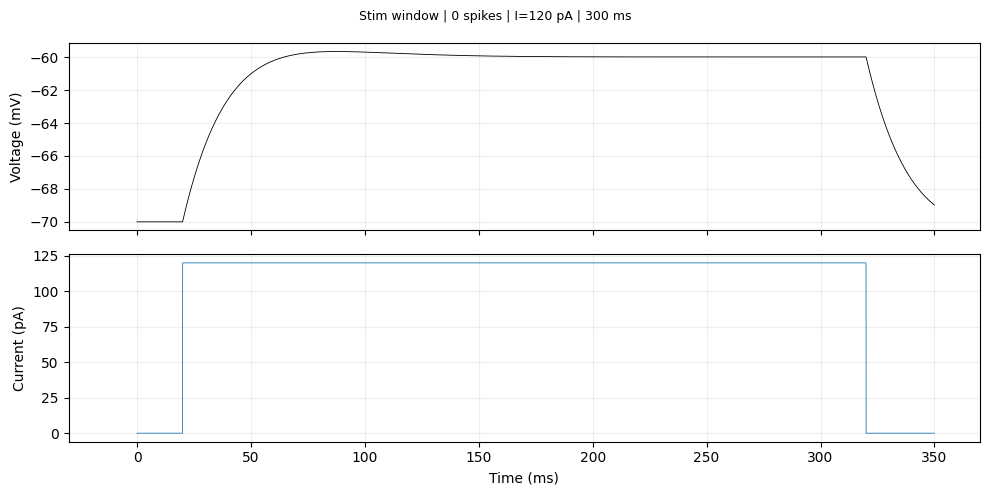

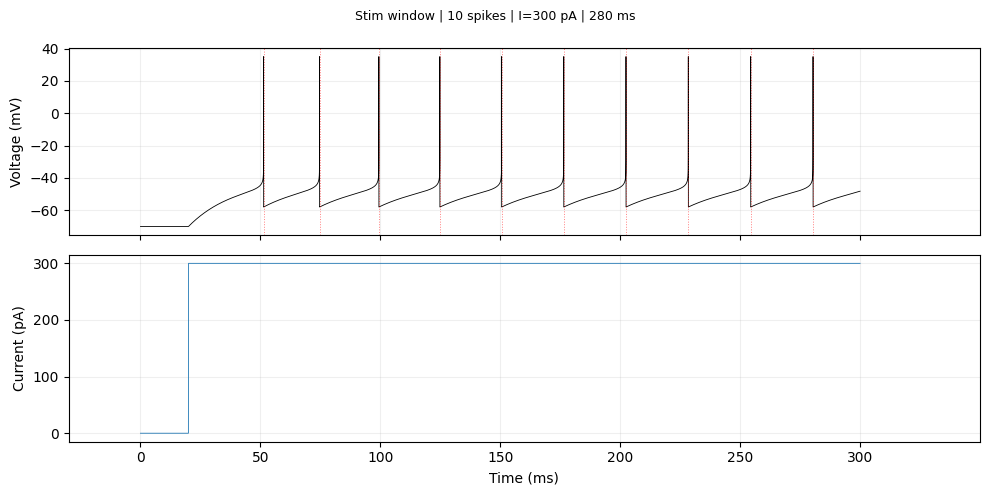

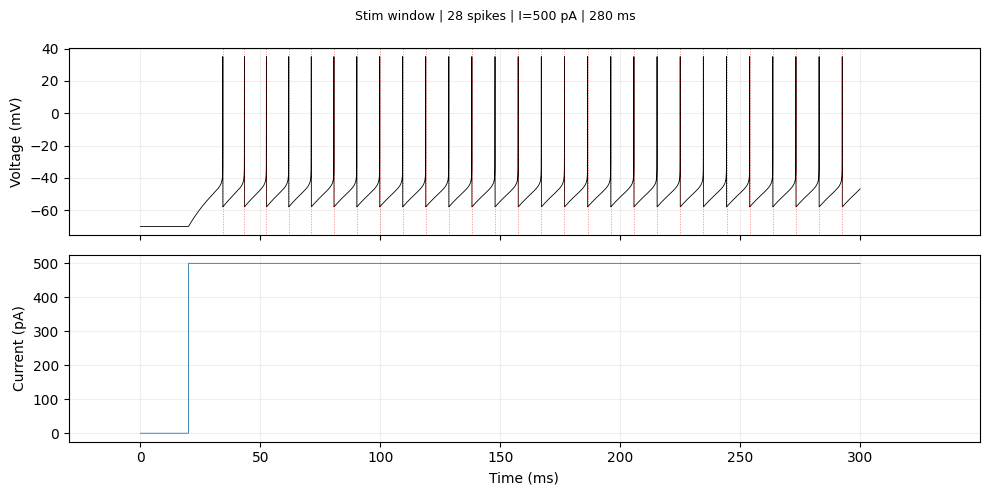

In [4]:
# --- Generate the three target traces ---
# Subthreshold trace: long pre-stim baseline so the MSE stages can crop around the
# stimulus onset / charging curve. Low current -> no spikes.
trace_sub = make_synthetic_trace(
    stim_current_pA=120.0, t_max_ms=350.0, stim_delay_ms=20.0, stim_duration_ms=300.0,
    gt_params=ground_truth_params,
)

# Spiking traces: moderate then high current.
trace_stim1 = make_synthetic_trace(
    stim_current_pA=300.0, t_max_ms=300.0, stim_delay_ms=20.0, stim_duration_ms=280.0,
    gt_params=ground_truth_params,
)
trace_stim2 = make_synthetic_trace(
    stim_current_pA=500.0, t_max_ms=300.0, stim_delay_ms=20.0, stim_duration_ms=280.0,
    gt_params=ground_truth_params,
)

for name, tr in [("subthreshold", trace_sub), ("stim1", trace_stim1), ("stim2", trace_stim2)]:
    print(f"{name:<12} {tr.stim_current_pA:>6.0f} pA -> {tr.n_spikes:>2d} spikes "
          f"({tr.n_samples} samples, {tr.duration_ms:.0f} ms)")
    trace_stim_window_plot(tr)

## 2. Perturbed Initial Parameters

Create initial parameters by adding relative noise to the ground truth. This simulates
the realistic scenario where the true values are unknown. The non-spiking defaults
(`v_T`, `delta_T`, `v_reset`, ...) used during the subthreshold stages are set exactly as
in `training_multistage`, then refined once the spiking stages begin.

In [5]:
PERTURBATION = 0.15  # relative perturbation (fraction of each parameter's bound range)

# Trainable groups per stage (mirrors training_multistage)
TRAINABLE_STAGE1 = ["C_m", "E_L", "g_L"]                                          # coarse subthreshold
TRAINABLE_STAGE2 = ["C_m", "E_L", "g_L"]                                          # refine subthreshold
TRAINABLE_STAGE3 = ["C_m", "E_L", "g_L", "v_T", "delta_T", "v_reset"]      # spike initiation
TRAINABLE_STAGE4 = ["C_m", "g_L", "E_L", "v_T", "delta_T", "v_reset",
                    "tau_w", "a", "b"]                                     # adaptation
TRAINABLE_STAGE5 = ["C_m", "g_L", "E_L", "v_T", "delta_T", "v_reset",
                    "tau_w", "a", "b"]                                     # Soft-DTW polish (all params)


def perturb_params(params, trainable, perturbation, key):
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = sorted(set(
    TRAINABLE_STAGE1 + TRAINABLE_STAGE2 + TRAINABLE_STAGE3 + TRAINABLE_STAGE4
    + TRAINABLE_STAGE5
))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
C_m               200.000      202.088     0.9%
E_L               -70.000      -66.927     6.8%
a                   2.000        2.502     5.0%
b                   0.000        0.000     0.0%
delta_T             2.000        3.389     7.3%
g_L                10.000        9.794     2.6%
tau_w              30.000       20.421     3.0%
v_T               -50.000      -49.148     3.4%
v_reset           -58.000      -57.400     1.7%


# Stage 1: Subthreshold fitting — coarse (`C_m`, `E_L`)
Crop the subthreshold trace around the stimulus onset and fit the coarse subthreshold
parameters with MSE.

Cropped trace: 1600 samples, 30.0 ms
Spikes in window: 0
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 0 spikes (target: 0)
{'C_m': 202.08799541927874, 'g_L': 9.794222921133041, 'E_L': -66.92653279751539, 'v_T': 0.0, 'delta_T': 1.0, 'v_reset': -100.0, 'v_threshold': 0.0, 'tau_w': 20.0, 'a': 0.0, 'b': 0.0, 'I': 500.0}


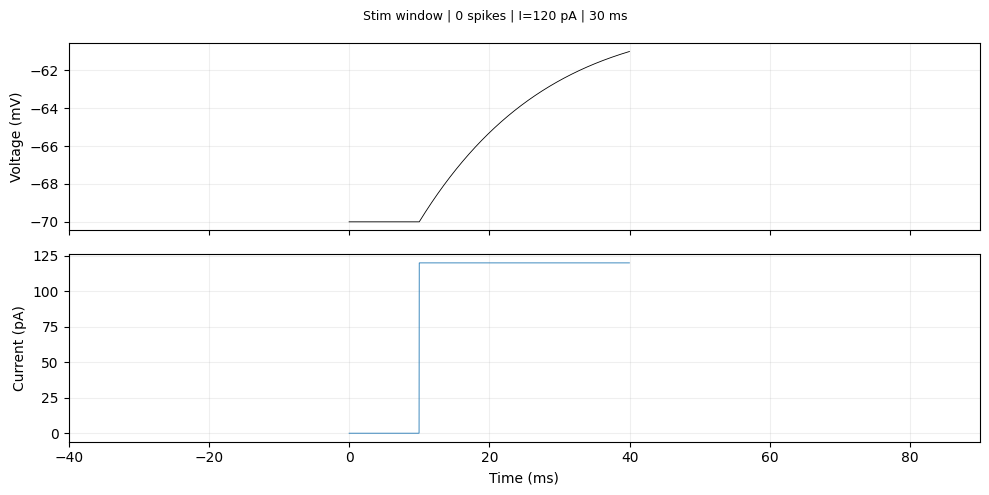

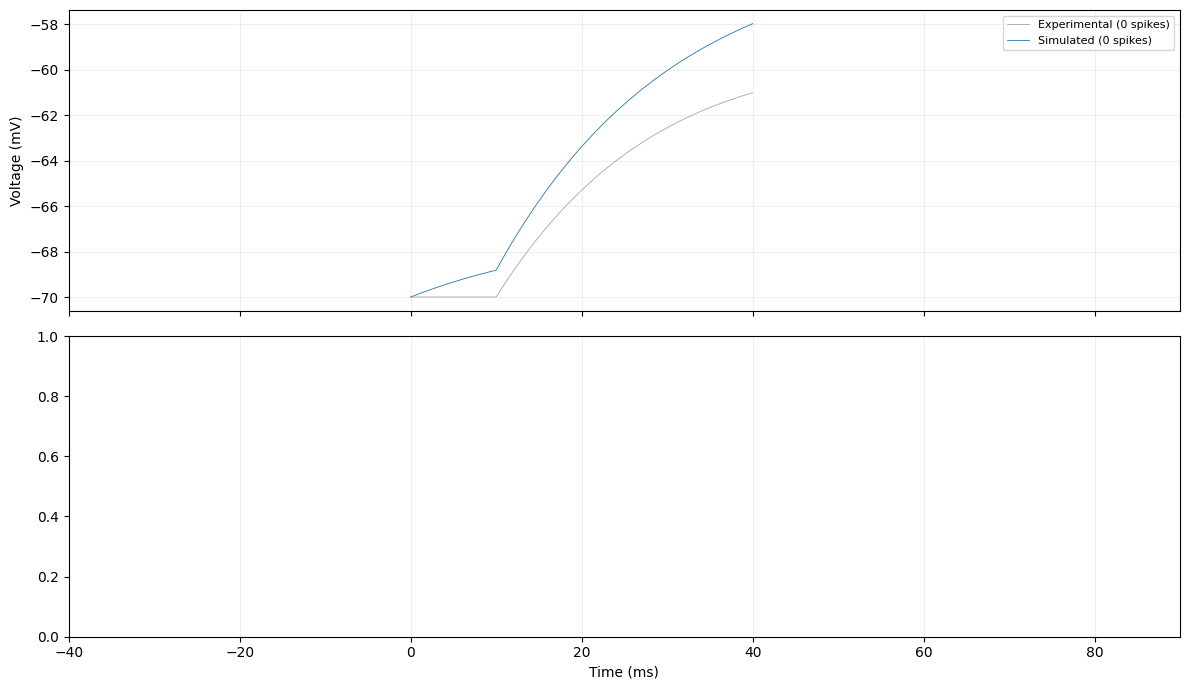

In [6]:
# Crop the subthreshold trace around the onset (short window -> coarse C_m, E_L)
data = crop_to_stim_window(trace_sub, max_duration_ms=30.0, padding_ms_before=10.0)
data_s1 = data  # keep this stage's window for the cross-stage comparison plot

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes}")
trace_stim_window_plot(data)

# Subthreshold defaults for the not-yet-fit spike-shape / adaptation parameters
initial_params["v_T"] = 0.0
initial_params["delta_T"] = 1.0
initial_params["v_reset"] = -100.0
initial_params["tau_w"] = 20.0
initial_params["a"] = 0.0
initial_params["b"] = 0.0

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)
sim_init_s1 = sim_init  # starting point for the "before" row of the comparison plot
print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

In [7]:
config_stage1 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.2,
    n_epochs=100,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=10,
    clip_to_bounds=False,
    use_param_transform=False,
    verbose=True,
    return_best=True,
)

cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage1,
    trainable_params=TRAINABLE_STAGE1,
)

loss_fn_stage1 = make_mse_loss_fn(
    cell=cell1, data_stimuli=data_stimuli1, t_max=t_max1, dt_ms=data.dt_ms,
    exp_voltage=data.voltage, stim_end_index=data.stim_end_idx,
)

print(f"Initial MSE loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3


Training: optimizer=adam lr=0.2 epochs=100 surrogate=superspike slope=10.0


Initial MSE loss: 3.9336


Epoch    0 | loss=3.933626 | grad_norm=2.37e+00 | C_m=202.2880, E_L=-67.1265, g_L=9.9942
Epoch   10 | loss=0.237167 | grad_norm=6.13e-01 | C_m=204.1039, E_L=-69.0016, g_L=11.8742
Epoch   20 | loss=0.234301 | grad_norm=5.92e-01 | C_m=204.9952, E_L=-69.9573, g_L=12.6884
Epoch   30 | loss=0.072318 | grad_norm=2.87e-01 | C_m=204.9199, E_L=-69.6854, g_L=12.0595
Epoch   40 | loss=0.035669 | grad_norm=2.09e-01 | C_m=204.7226, E_L=-69.3538, g_L=11.3863
Epoch   50 | loss=0.016917 | grad_norm=1.24e-01 | C_m=204.8502, E_L=-69.5165, g_L=11.3287
Epoch   60 | loss=0.010536 | grad_norm=7.15e-02 | C_m=204.9809, E_L=-69.7145, g_L=11.3353
Epoch   70 | loss=0.004653 | grad_norm=1.73e-02 | C_m=204.9364, E_L=-69.6991, g_L=11.0968
Epoch   80 | loss=0.003667 | grad_norm=4.15e-02 | C_m=204.9019, E_L=-69.7016, g_L=10.9178
Epoch   90 | loss=0.002134 | grad_norm=6.36e-03 | C_m=204.9188, E_L=-69.7699, g_L=10.8627
Training complete: final_loss=0.001773 best_loss=0.001773 (epoch 99) total_time=0.6s mean_epoch=5.9ms


Stage 1 complete.
  Best loss:   0.0018
  Total time:  0.6 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 0 spikes (target: 0)
Recovered vs ground truth:
  C_m           204.908  (GT: 200.000)
  E_L           -69.795  (GT: -70.000)
  g_L            10.801  (GT: 10.000)


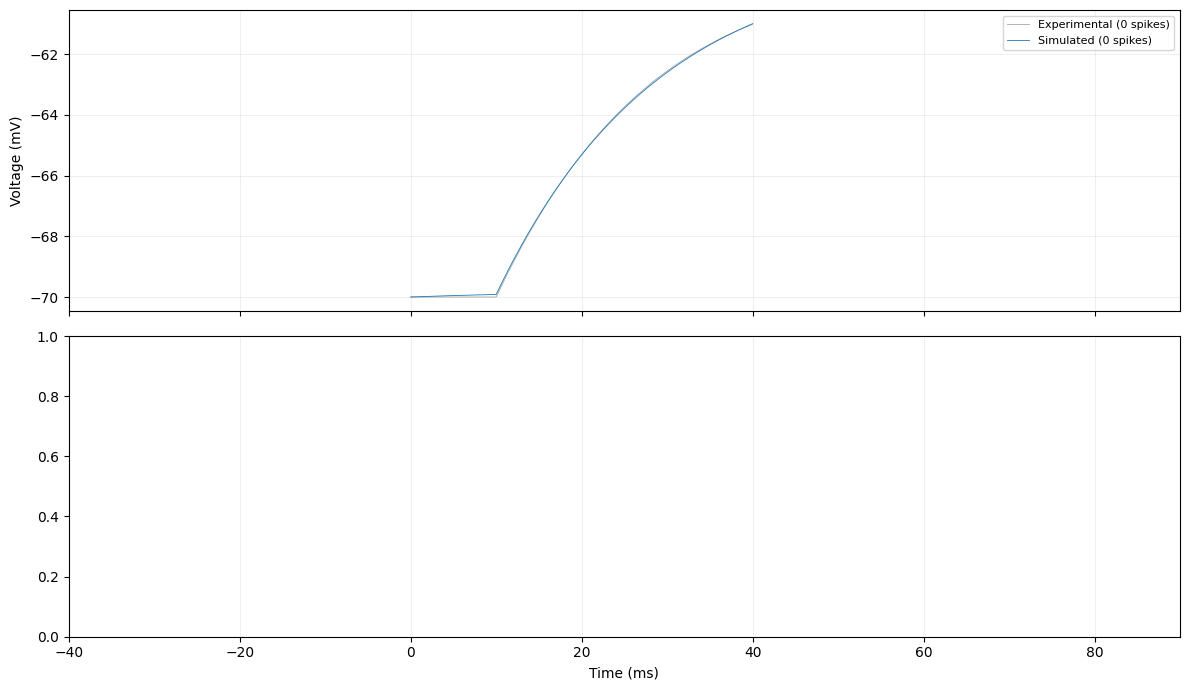

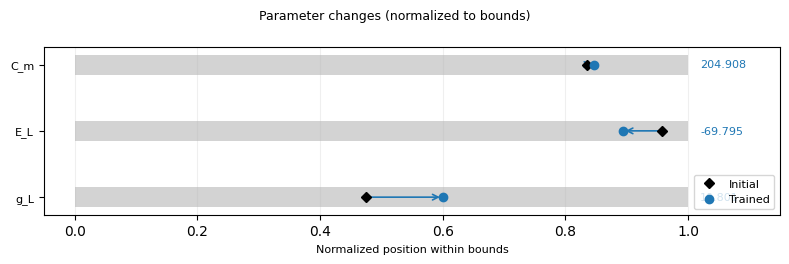

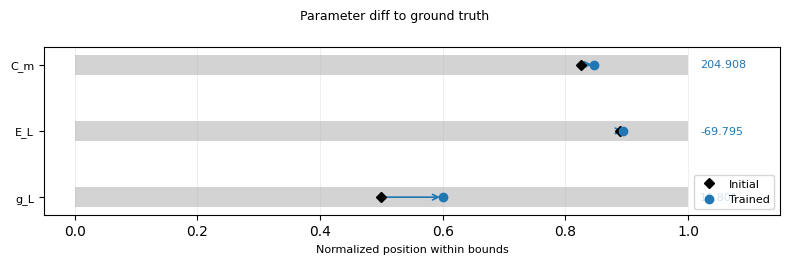

In [8]:
# Evaluate stage 1
params_after_s1 = dict(initial_params)
params_after_s1.update(result_stage1.get_params_dict())

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")
print("Recovered vs ground truth:")
for k in TRAINABLE_STAGE1:
    print(f"  {k:<10} {params_after_s1[k]:>10.3f}  (GT: {ground_truth_params[k]:.3f})")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1)
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    config=result_stage1.config,
    initial_params=ground_truth_params), figtitle="Parameter diff to ground truth");

# Stage 2: Subthreshold fitting — refine (`E_L`, `g_L`)
Use a longer window over the full charging curve and refine `E_L`, `g_L` with MSE,
starting from the Stage 1 fit.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
{'C_m': 204.90835571289062, 'g_L': 10.80078125, 'E_L': -69.79508209228516, 'v_T': 0.0, 'delta_T': 1.0, 'v_reset': -100.0, 'v_threshold': 0.0, 'tau_w': 20.0, 'a': 0.0, 'b': 0.0, 'I': 500.0}


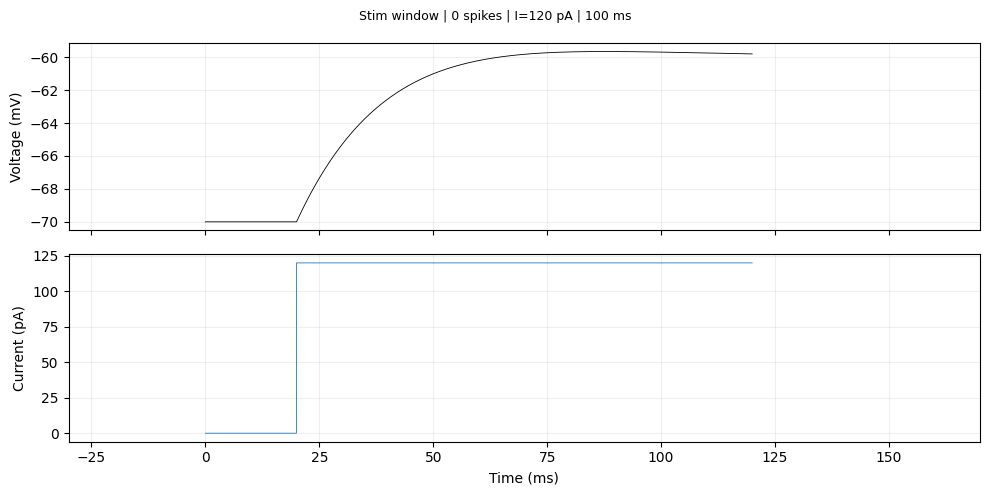

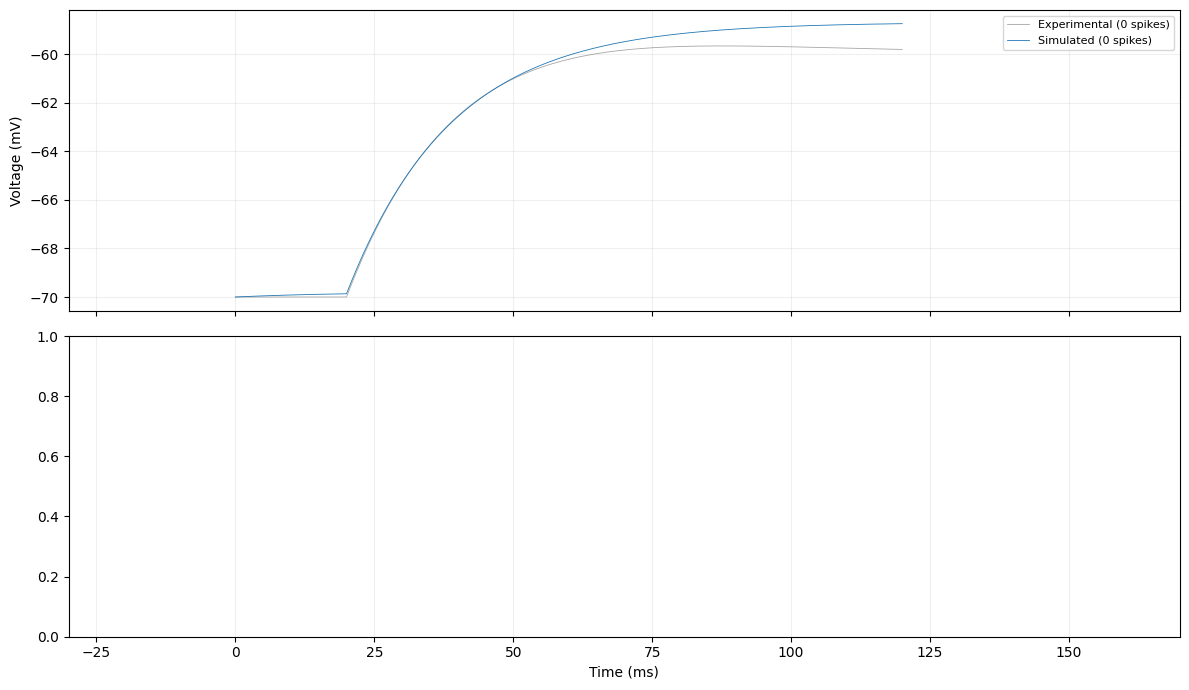

In [9]:
# Longer window over the charging curve -> constrains E_L, g_L
data = crop_to_stim_window(trace_sub, max_duration_ms=100.0, padding_ms_before=30.0)
trace_stim_window_plot(data)

initial_params = params_after_s1.copy()

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)
fit_comparison_plot(data, sim_init)
print(initial_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3


Training: optimizer=adam lr=0.05 epochs=100 surrogate=superspike slope=10.0


Initial MSE loss: 0.2609


Epoch    0 | loss=0.260906 | grad_norm=8.63e-01 | C_m=204.9584, E_L=-69.8451, g_L=10.8508
Epoch   10 | loss=0.085680 | grad_norm=2.97e-01 | C_m=204.9342, E_L=-70.1633, g_L=11.2315
Epoch   20 | loss=0.055868 | grad_norm=6.75e-02 | C_m=204.4496, E_L=-69.9716, g_L=11.2433
Epoch   30 | loss=0.050609 | grad_norm=1.20e-01 | C_m=204.0308, E_L=-69.8662, g_L=11.3351
Epoch   40 | loss=0.041864 | grad_norm=7.91e-02 | C_m=203.6657, E_L=-69.8580, g_L=11.4956
Epoch   50 | loss=0.036836 | grad_norm=2.81e-02 | C_m=203.2778, E_L=-69.7632, g_L=11.5557
Epoch   60 | loss=0.034531 | grad_norm=1.35e-02 | C_m=202.9400, E_L=-69.7322, g_L=11.6358
Epoch   70 | loss=0.033318 | grad_norm=1.16e-02 | C_m=202.6212, E_L=-69.7045, g_L=11.6865
Epoch   80 | loss=0.032646 | grad_norm=1.12e-02 | C_m=202.3187, E_L=-69.6822, g_L=11.7133
Epoch   90 | loss=0.032127 | grad_norm=5.77e-03 | C_m=202.0330, E_L=-69.6787, g_L=11.7334
Training complete: final_loss=0.031817 best_loss=0.031817 (epoch 99) total_time=0.4s mean_epoch=4.3m


Stage 2 complete.
  Best loss:   0.0318
  Total time:  0.4 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 2: 0 spikes (target: 0)
Recovered vs ground truth:
  C_m           201.807  (GT: 200.000)
  E_L           -69.674  (GT: -70.000)
  g_L            11.736  (GT: 10.000)


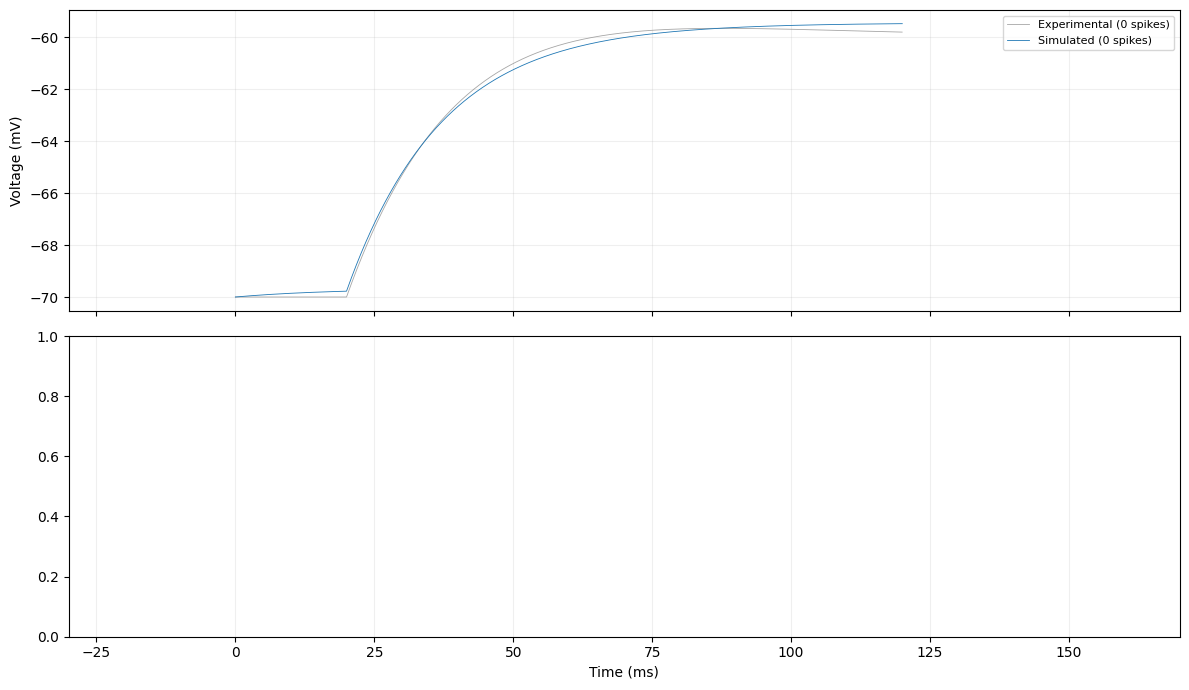

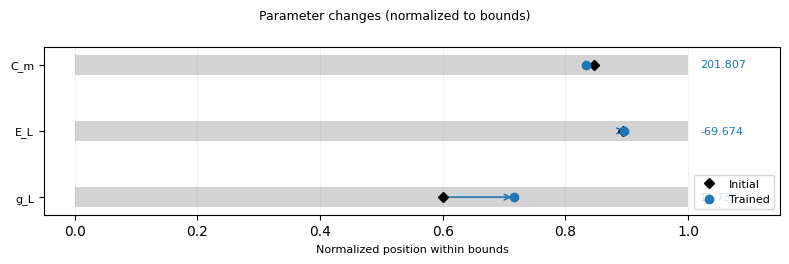

In [10]:
config_stage2 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.05,
    n_epochs=100,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=10,
    clip_to_bounds=False,
    use_param_transform=False,
    verbose=True,
    return_best=True,
)

cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage2,
    trainable_params=TRAINABLE_STAGE2,
)

loss_fn_stage2 = make_mse_loss_fn(
    cell=cell2, data_stimuli=data_stimuli2, t_max=t_max2, dt_ms=data.dt_ms,
    exp_voltage=data.voltage, stim_end_index=data.stim_end_idx,
)

print(f"Initial MSE loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=initial_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

# Evaluate stage 2
params_after_s2 = dict(initial_params)
params_after_s2.update(result_stage2.get_params_dict())

sim_stage2 = simulate_with_current_trace(
    params=params_after_s2,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 2: {sim_stage2.n_spikes} spikes (target: {data.n_spikes})")
print("Recovered vs ground truth:")
for k in TRAINABLE_STAGE2:
    print(f"  {k:<10} {params_after_s2[k]:>10.3f}  (GT: {ground_truth_params[k]:.3f})")

fit_comparison_plot(data, sim_stage2)
parameter_comparison_plot(result_stage2);

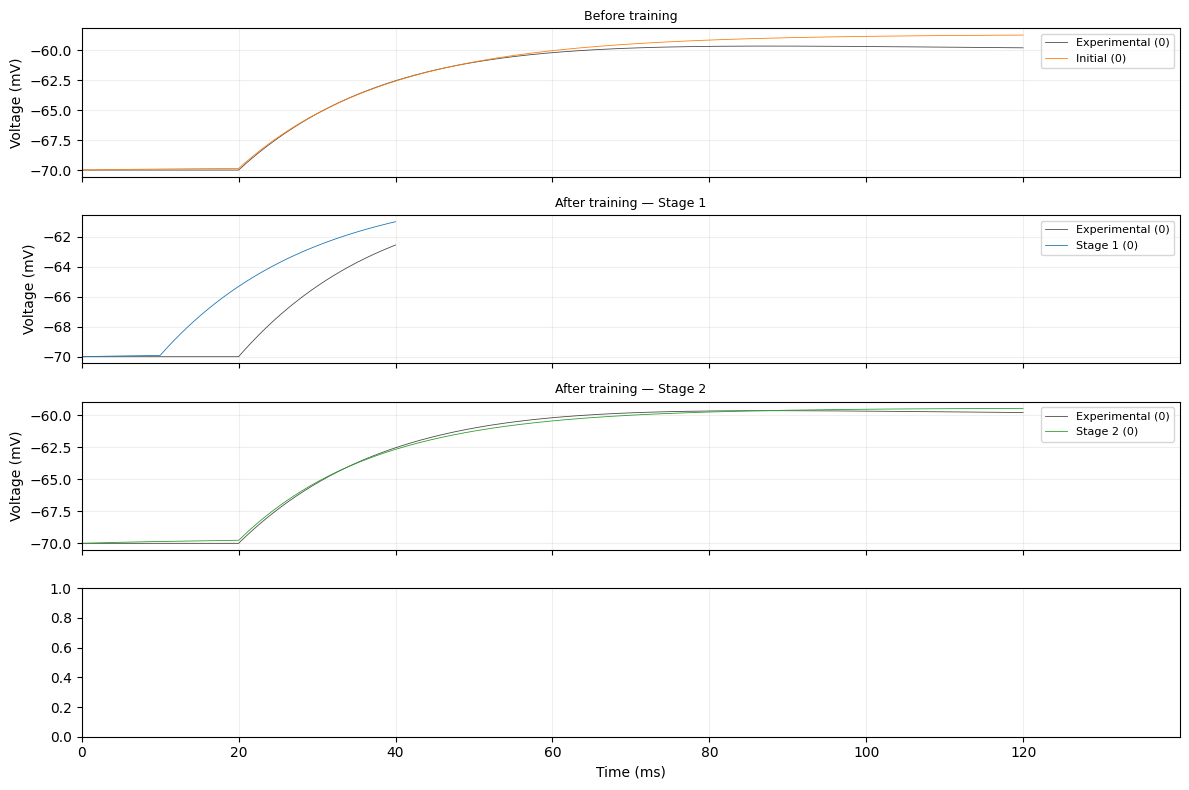

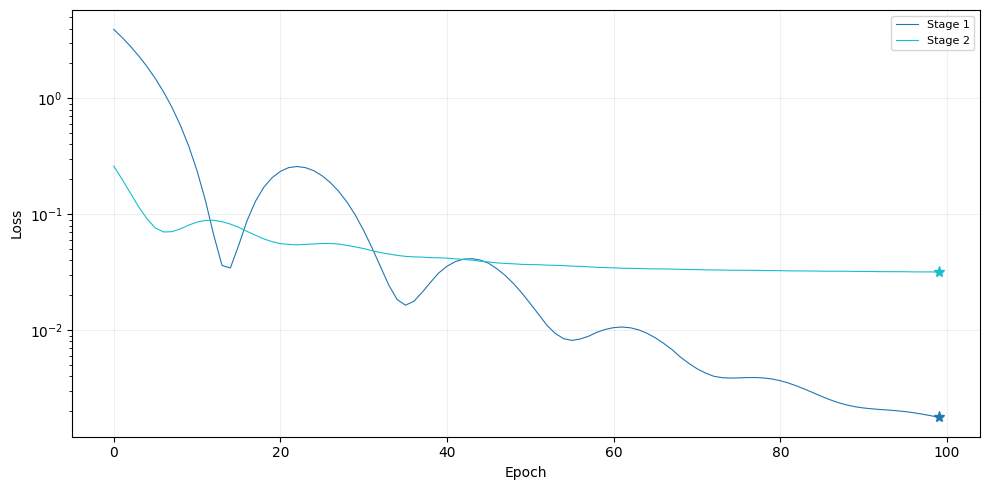

In [11]:
fit_before_after_plot(
    data,               # data should also be an array, [data1, data2, ...] for the stimulation etc. used in the specific stage
    sim_init,
    [sim_stage1, sim_stage2],
    coincidence=[None, None],
    labels=["Stage 1", "Stage 2"],
)

training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1", "Stage 2"],
    show_grad_norms=False,
);

# Stage 3: Spiking regime — spike initiation (Guarino)
Switch to the `stim1` spiking trace and fit the spike-initiation parameters (`v_T`,
`delta_T`, `v_reset`) together with the subthreshold parameters using the Guarino feature
loss. Carries over the subthreshold fit from Stage 2 and seeds the spike-shape /
adaptation parameters with physiological values.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 7 spikes (target: 10)
{'C_m': 201.80650329589844, 'g_L': 11.736268043518066, 'E_L': -69.6736831665039, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -60.0, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 2.0, 'b': 0.0, 'I': 500.0}


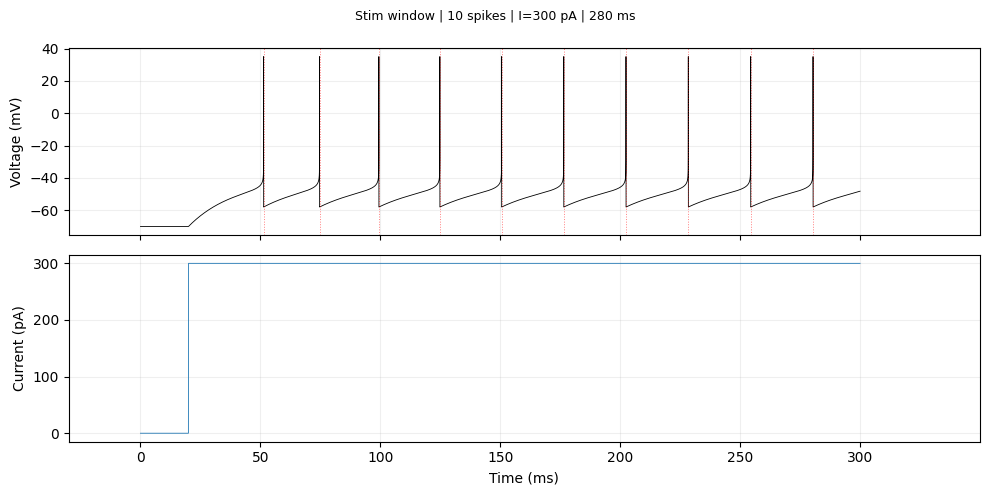

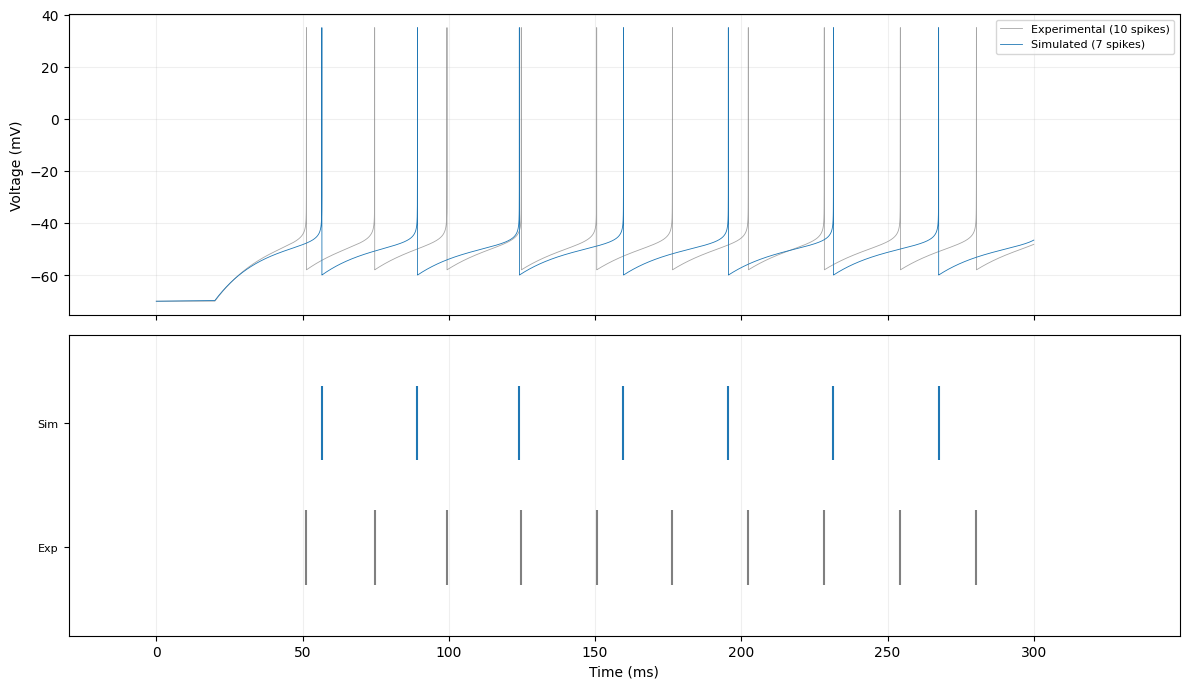

In [12]:
data = trace_stim1
trace_stim_window_plot(data)

# Carry over the subthreshold-fit parameters (C_m, E_L, g_L) from stage 2
initial_params = params_after_s2.copy()

# Physiological spiking defaults for the spike-shape / adaptation parameters
initial_params["v_T"] = -50.0
initial_params["delta_T"] = 2.0
initial_params["v_reset"] = -60.0
initial_params["tau_w"] = 30.0
initial_params["a"] = 2.0
initial_params["b"] = 0.0

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


Training: optimizer=adam lr=0.5 epochs=100 surrogate=superspike slope=10.0


Initial TTFS loss: 0.4078


Epoch    0 | loss=0.407759 | grad_norm=4.45e-02 | C_m=201.3065, E_L=-69.1737, g_L=11.2363, v_T=-50.5000, delta_T=1.5000, v_reset=-59.5000
Epoch   10 | loss=0.462994 | grad_norm=2.26e-01 | C_m=202.0904, E_L=-69.9586, g_L=12.0232, v_T=-49.7124, delta_T=2.2891, v_reset=-58.0699
Epoch   20 | loss=1.158240 | grad_norm=4.41e+02 | C_m=202.7818, E_L=-70.6501, g_L=12.7146, v_T=-49.0210, delta_T=2.9805, v_reset=-57.3785
Epoch   30 | loss=1.696781 | grad_norm=2.02e+01 | C_m=203.0486, E_L=-70.9169, g_L=12.9815, v_T=-48.7541, delta_T=3.2474, v_reset=-57.1117
Epoch   40 | loss=1.942340 | grad_norm=2.52e+01 | C_m=203.1536, E_L=-71.0219, g_L=13.0864, v_T=-48.6492, delta_T=3.3523, v_reset=-57.0067
Epoch   50 | loss=2.081099 | grad_norm=7.97e+01 | C_m=203.1945, E_L=-71.0627, g_L=13.1273, v_T=-48.6083, delta_T=3.3932, v_reset=-56.9658
Epoch   60 | loss=2.146679 | grad_norm=8.24e+00 | C_m=203.2102, E_L=-71.0784, g_L=13.1430, v_T=-48.5926, delta_T=3.4089, v_reset=-56.9501
Epoch   70 | loss=2.172759 | grad_


Stage 3 complete.
  Best loss:   0.0124
  Total time:  0.7 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 3: 10 spikes (target: 10)
Gamma = 0.533


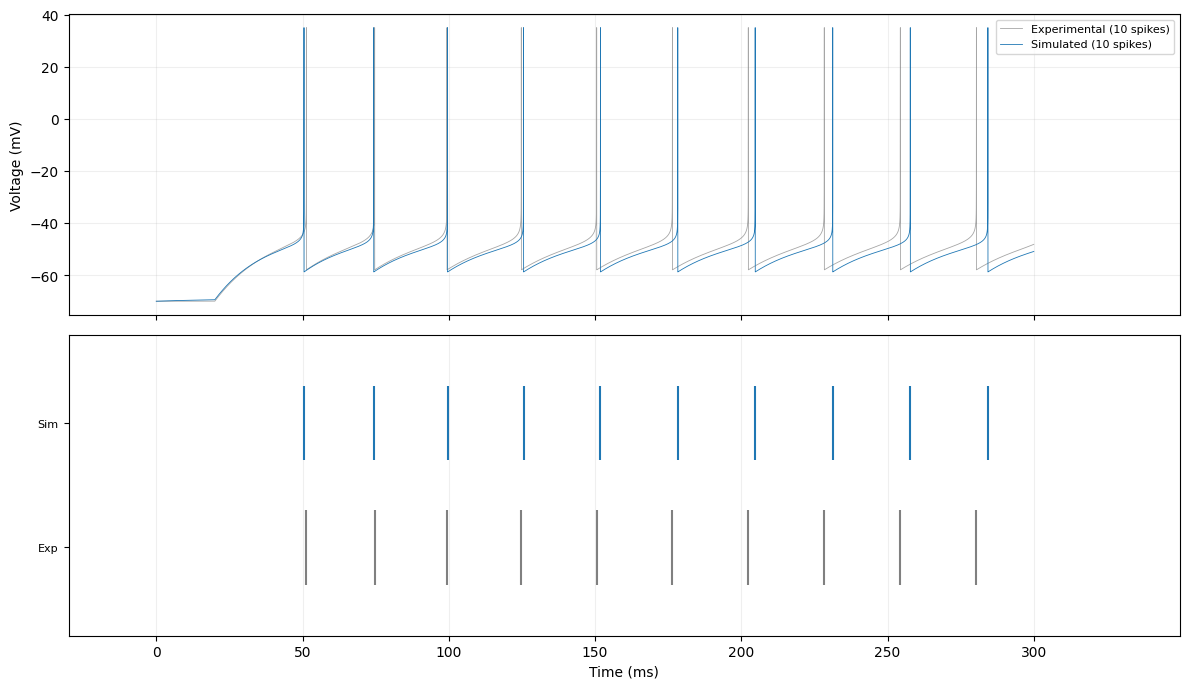

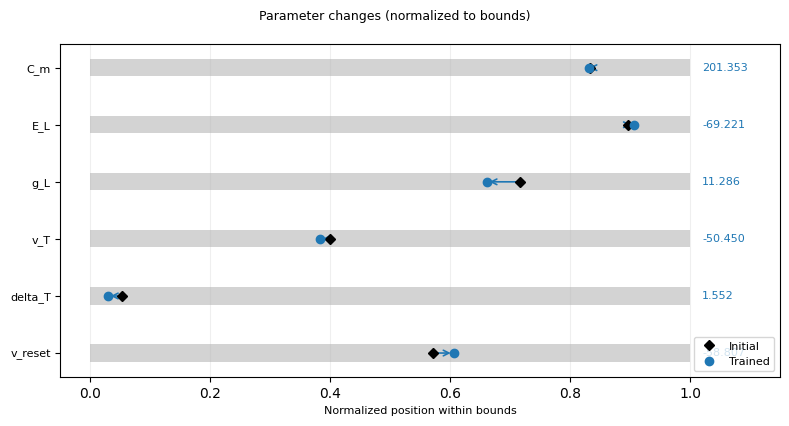

In [13]:
config_stage3 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.5,
    n_epochs=100,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=10,
    clip_to_bounds=False,
    use_param_transform=False,
    verbose=True,
    return_best=True,
)

cell3, data_stimuli3, t_max3, trainable_params3 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage3,
    trainable_params=TRAINABLE_STAGE3,
)

exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    spike_threshold_mv=-10.0,
)

loss_fn_stage3 = make_ttfs_rate_loss_fn(
    cell=cell3,
    data_stimuli=data_stimuli3,
    t_max=t_max3,
    dt_ms=data.dt_ms,
    exp_t_first_spike=exp_features.t_first_spike,
    exp_firing_frequency=exp_features.firing_frequency,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

print(f"Initial TTFS loss: {float(loss_fn_stage3(trainable_params3)):.4f}")

result_stage3 = train(
    loss_fn=loss_fn_stage3,
    trainable_params=trainable_params3,
    config=config_stage3,
    initial_params=initial_params,
)

print(f"\nStage 3 complete.")
print(f"  Best loss:   {result_stage3.best_loss:.4f}")
print(f"  Total time:  {result_stage3.total_time:.1f} s")

# Evaluate stage 3
params_after_s3 = dict(initial_params)
params_after_s3.update(result_stage3.get_params_dict())

sim_stage3 = simulate_with_current_trace(
    params=params_after_s3,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 3: {sim_stage3.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage3.n_spikes > 0 and data.n_spikes > 0:
    cf_s3 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage3.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s3.gamma:.3f}")
else:
    cf_s3 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage3)
parameter_comparison_plot(result_stage3);

# Stage 4: Spiking regime — adaptation (Guarino)
Move to the higher-current `stim2` trace (richer adaptation dynamics) and fit the
adaptation parameters (`tau_w`, `a`, `b`) along with everything fit so far, using the
Guarino feature loss. Carries over the Stage 3 fit.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 10 spikes (target: 10)
{'C_m': 201.35308837890625, 'g_L': 11.285911560058594, 'E_L': -69.22135925292969, 'v_T': -50.44967269897461, 'delta_T': 1.551809310913086, 'v_reset': -58.80719757080078, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': 2.0, 'b': 0.0, 'I': 500.0}


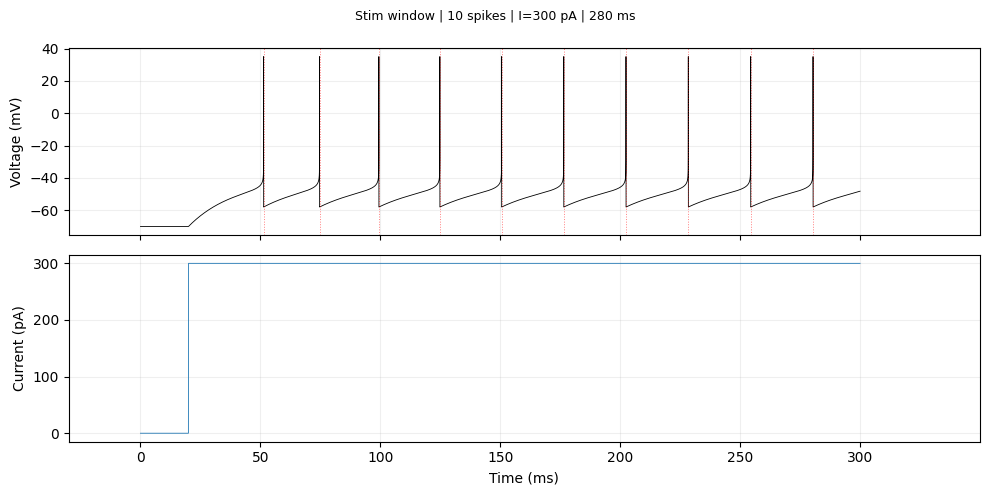

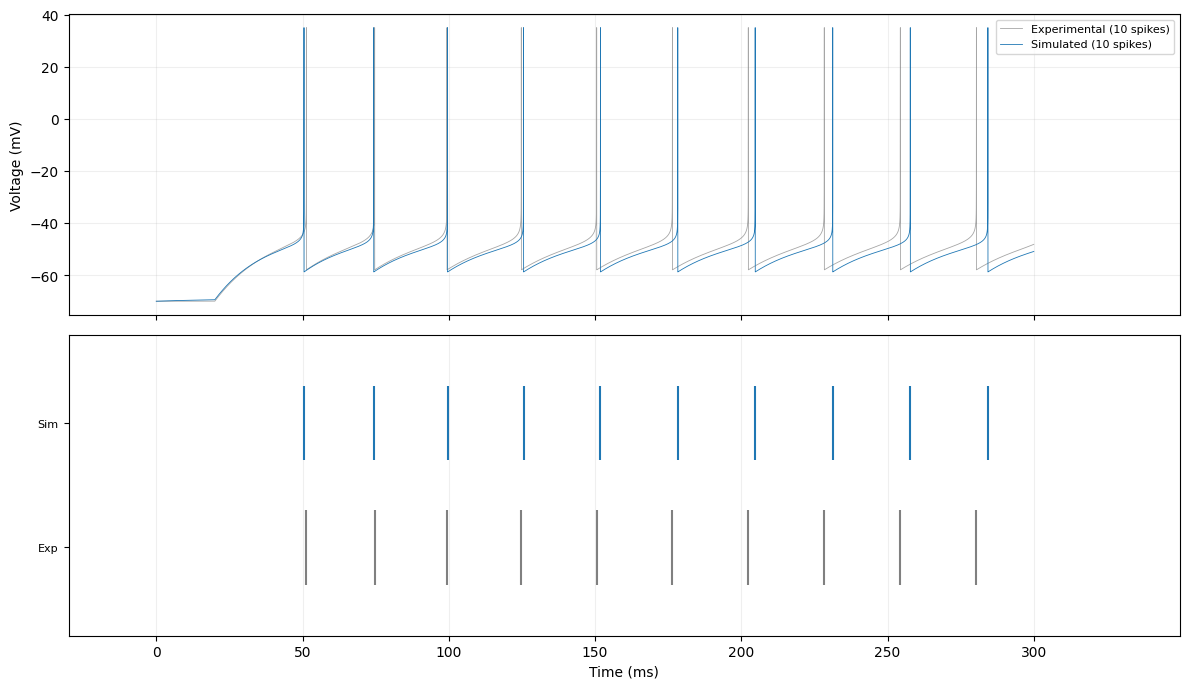

In [14]:
data = trace_stim1
trace_stim_window_plot(data)

# Carry over all previously fit parameters from stage 3
initial_params = params_after_s3.copy()

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9


Training: optimizer=adam lr=0.005 epochs=100 surrogate=superspike slope=5.0 sigmoid_transform


Initial Guarino loss: 0.1319


Epoch    0 | loss=0.132412 | grad_norm=3.40e+08 | C_m=201.1921, g_L=11.2769, E_L=-69.2023, v_T=-50.4792, delta_T=1.5491, v_reset=-58.8490, tau_w=30.1279, a=1.9895, b=0.0065
Epoch   10 | loss=0.807769 | grad_norm=3.03e+13 | C_m=200.6375, g_L=11.2461, E_L=-69.1374, v_T=-50.5799, delta_T=1.5401, v_reset=-58.9943, tau_w=30.5718, a=1.9533, b=0.0066
Epoch   20 | loss=0.118369 | grad_norm=8.99e+08 | C_m=200.9238, g_L=11.2617, E_L=-69.1697, v_T=-50.5286, delta_T=1.5448, v_reset=-58.9423, tau_w=30.3501, a=1.9721, b=0.0066
Epoch   30 | loss=0.110152 | grad_norm=3.38e+11 | C_m=201.2523, g_L=11.2798, E_L=-69.2079, v_T=-50.4688, delta_T=1.5503, v_reset=-58.8746, tau_w=30.0908, a=1.9938, b=0.0066
Epoch   40 | loss=0.132691 | grad_norm=1.08e+09 | C_m=201.3307, g_L=11.2839, E_L=-69.2166, v_T=-50.4553, delta_T=1.5516, v_reset=-58.8484, tau_w=30.0387, a=1.9981, b=0.0065
Epoch   50 | loss=0.172801 | grad_norm=3.13e+09 | C_m=200.7344, g_L=11.2505, E_L=-69.1461, v_T=-50.5644, delta_T=1.5418, v_reset=-59.00


Stage 4 complete.
  Best loss:   0.0764
  Total time:  1.2 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 4: 10 spikes (target: 10)
Gamma = 1.000


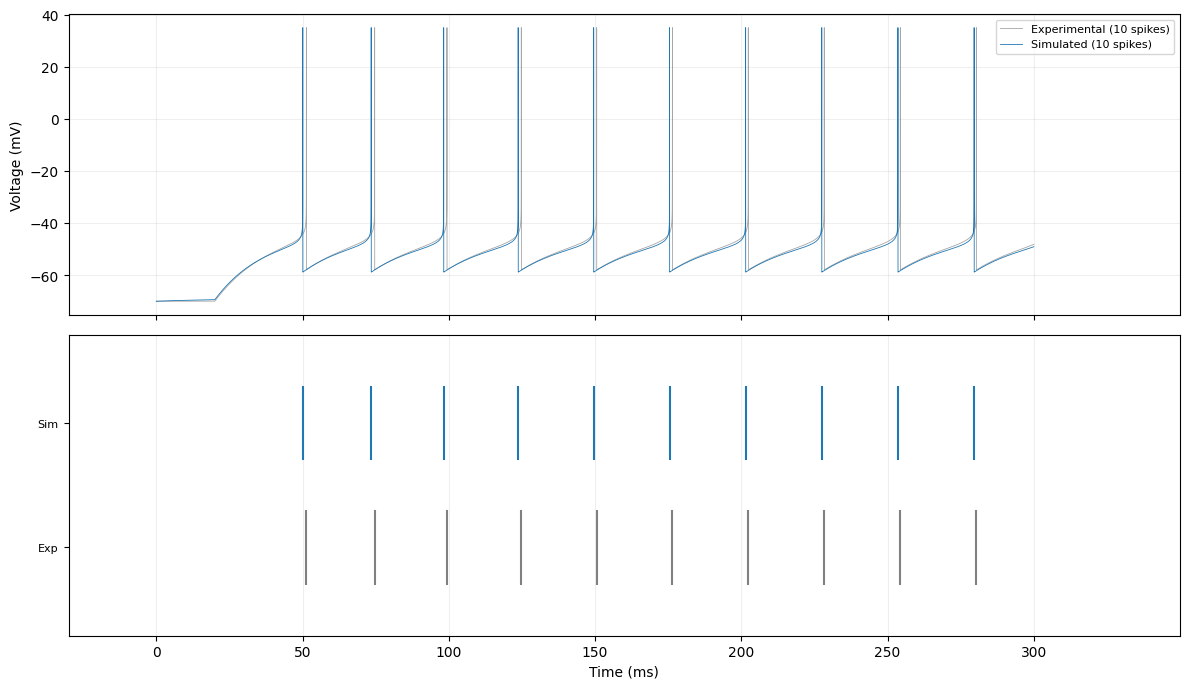

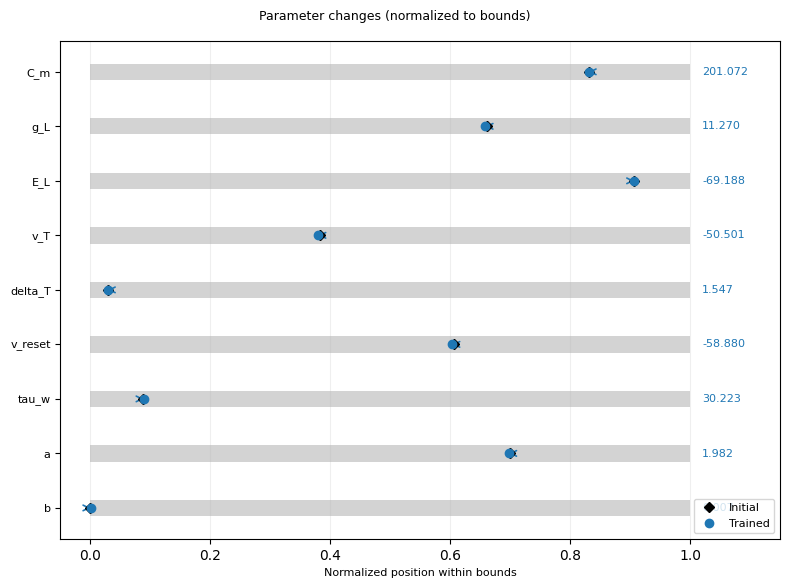

In [15]:
config_stage4 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.005,
    n_epochs=100,
    surrogate_type="superspike",
    surrogate_slope=5.0,
    print_every=10,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

cell4, data_stimuli4, t_max4, trainable_params4 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage4,
    trainable_params=TRAINABLE_STAGE4,
)

exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    spike_threshold_mv=-10.0,
)
loss_fn_stage4 = make_guarino_loss_fn(
    cell=cell4, data_stimuli=data_stimuli4, t_max=t_max4, dt_ms=data.dt_ms,
    exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(weight_spike_count=0.3),
    temperature=0.3, beta=5, validity_beta=5,
)

print(f"Initial Guarino loss: {float(loss_fn_stage4(trainable_params4)):.4f}")

result_stage4 = train(
    loss_fn=loss_fn_stage4,
    trainable_params=trainable_params4,
    config=config_stage4,
    initial_params=initial_params,
)

print(f"\nStage 4 complete.")
print(f"  Best loss:   {result_stage4.best_loss:.4f}")
print(f"  Total time:  {result_stage4.total_time:.1f} s")

# Evaluate stage 4
params_after_s4 = dict(initial_params)
params_after_s4.update(result_stage4.get_params_dict())

sim_stage4 = simulate_with_current_trace(
    params=params_after_s4,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 4: {sim_stage4.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage4.n_spikes > 0 and data.n_spikes > 0:
    cf_s4 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage4.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s4.gamma:.3f}")
else:
    cf_s4 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage4)
parameter_comparison_plot(result_stage4);

# Stage 5: Spiking regime — temporal alignment (Soft-DTW)
Final refinement on the `stim1` spiking trace using **soft dynamic time warping**
(Deistler et al. supplement recipe). Unlike the Guarino feature loss, soft-DTW compares
the full preprocessed voltage trace under an optimal temporal alignment, giving a smooth
timing-aware gradient that polishes the spike *timing* of every parameter fit so far.
Carries over the Stage 4 fit and refines all parameters.

Preprocessing follows the Deistler recipe: a sliding-window max reduction (window 50,
stride 30) injected with spike peaks, then unit rescaling. The cost combines an L1
amplitude term with a normalized temporal penalty (`lambda_temp`), and the loss is the
Cuturi & Blondel divergence so it is non-negative and reaches 0 at a perfect fit.

In [16]:
# --- Soft-DTW loss (Deistler et al. supplement recipe) ---
# Defined inline (notebook-first workflow; the library has no DTW module). Pipeline:
# sliding-window max reduction -> unit rescale -> soft-DTW with an L1 amplitude +
# normalized temporal-penalty cost, returned as the Cuturi & Blondel divergence so the
# loss is >= 0 and = 0 at a perfect fit.


def sliding_window_max(v, window_size, stride):
    """Sliding-window max reduction via jax.lax.reduce_window (differentiable)."""
    return jax.lax.reduce_window(
        v,
        init_value=-jnp.inf,
        computation=jax.lax.max,
        window_dimensions=(window_size,),
        window_strides=(stride,),
        padding="VALID",
    )


def rescale_unit(v, v_min, v_max, eps=1e-8):
    """Rescale to [0, 1] using pre-computed min/max (shared across sim and target)."""
    return (v - v_min) / (v_max - v_min + eps)


_LARGE = 1e9  # stand-in for +inf; softmin treats -_LARGE/gamma as negligible


def _softmin(values, gamma):
    return -gamma * logsumexp(-values / gamma)


def soft_dtw_from_cost(C, gamma=1.0):
    """Soft-DTW distance from a pre-built cost matrix C of shape (n, m).

    R[0, 0] = 0; R[0, j>0] = R[i>0, 0] = +inf (approximated by _LARGE).
    R[i, j] = C[i-1, j-1] + softmin_gamma(R[i-1, j-1], R[i-1, j], R[i, j-1]).
    """
    n, m = C.shape

    def process_row(R_prev, C_row):
        def col_step(R_curr_prev, inputs):
            R_diag, R_up, C_val = inputs
            R_curr = C_val + _softmin(jnp.stack([R_diag, R_up, R_curr_prev]), gamma)
            return R_curr, R_curr

        col_inputs = (R_prev[:-1], R_prev[1:], C_row)
        _, R_curr_rest = jax.lax.scan(col_step, _LARGE, col_inputs)
        R_curr = jnp.concatenate([jnp.array([_LARGE]), R_curr_rest])
        return R_curr, None

    R_init = jnp.concatenate([jnp.zeros(1), jnp.full(m, _LARGE)])
    R_final, _ = jax.lax.scan(process_row, R_init, C)
    return R_final[-1]


def make_soft_dtw_loss_fn(
    cell, data_stimuli, t_max, dt_ms, exp_voltage, stim_end_index, *,
    window_size=50, stride=30, gamma=0.5, lambda_temp=10.0,
    spike_peak_mv=35.0, use_divergence=True,
):
    """Build a closure `params -> scalar soft-DTW loss` on the preprocessed traces.

    Cost: C[i, j] = |x_i - y_j| + lambda_temp * |i - j| / (n - 1); both terms in
    [0, 1], so lambda_temp directly trades timing vs amplitude. With
    use_divergence=True returns the Cuturi & Blondel divergence
    D(x, y) = sdtw(x, y) - 0.5 * (sdtw(x, x) + sdtw(y, y)) (>= 0, = 0 when x = y),
    removing soft-DTW's length-dependent bias.
    """
    import jaxley as jx

    exp_v = jnp.asarray(exp_voltage)
    exp_reduced = sliding_window_max(exp_v, window_size, stride)
    v_min = float(jnp.min(exp_reduced))
    v_max = float(jnp.max(exp_reduced))
    exp_scaled = rescale_unit(exp_reduced, v_min, v_max)
    m = exp_scaled.shape[0]

    # Precompute sdtw(y, y) — constant baseline used by the divergence form.
    if use_divergence:
        j_idx_y = jnp.arange(m, dtype=exp_scaled.dtype)
        denom_y = jnp.maximum(jnp.asarray(m - 1, dtype=exp_scaled.dtype), 1.0)
        C_yy = jnp.abs(exp_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(j_idx_y[:, None] - j_idx_y[None, :]) / denom_y
        )
        sdtw_yy = soft_dtw_from_cost(C_yy, gamma=gamma)
    else:
        sdtw_yy = jnp.asarray(0.0, dtype=exp_scaled.dtype)

    def loss_fn(params):
        results = jx.integrate(
            cell, params=params, data_stimuli=data_stimuli,
            delta_t=dt_ms, t_max=t_max,
        )
        voltage = results[0].flatten()
        min_len = min(len(voltage), len(exp_v))
        sim_v = voltage[:min_len]

        # Inject peaks at spike timesteps so the sliding-window max sees the same
        # peak height the target trace was built with (results[2] is the 0/1 spike
        # indicator from AdExSurrogate's forward pass).
        if spike_peak_mv is not None:
            spikes = results[2].flatten()[:min_len]
            sim_v = inject_spike_peaks(sim_v, spikes, spike_peak_mv)

        sim_reduced = sliding_window_max(sim_v, window_size, stride)
        sim_scaled = rescale_unit(sim_reduced, v_min, v_max)
        n = sim_scaled.shape[0]

        denom = jnp.maximum(jnp.asarray(max(n, m) - 1, dtype=exp_scaled.dtype), 1.0)
        i_idx = jnp.arange(n, dtype=exp_scaled.dtype)[:, None]
        j_idx = jnp.arange(m, dtype=exp_scaled.dtype)[None, :]
        C_xy = jnp.abs(sim_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_idx - j_idx) / denom
        )
        sdtw_xy = soft_dtw_from_cost(C_xy, gamma=gamma)

        if not use_divergence:
            return sdtw_xy

        i_only = jnp.arange(n, dtype=exp_scaled.dtype)
        C_xx = jnp.abs(sim_scaled[:, None] - sim_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_only[:, None] - i_only[None, :]) / denom
        )
        sdtw_xx = soft_dtw_from_cost(C_xx, gamma=gamma)

        return sdtw_xy - 0.5 * (sdtw_xx + sdtw_yy)

    return loss_fn


# Sanity check: soft-DTW of a sequence with itself should be ~0
_toy = jnp.array([0.0, 1.0, 2.0, 1.0, 0.0])
_i, _j = jnp.arange(5)[:, None], jnp.arange(5)[None, :]
_C = jnp.abs(_toy[:, None] - _toy[None, :]) + jnp.abs(_i - _j)
print(f"Soft-DTW(identical) ~ {float(soft_dtw_from_cost(_C, gamma=1.0)):.4f}")

Soft-DTW(identical) ~ -1.0337


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 10 spikes (target: 10)
{'C_m': 201.0718994140625, 'g_L': 11.27025032043457, 'E_L': -69.18811798095703, 'v_T': -50.5010871887207, 'delta_T': 1.5471560955047607, 'v_reset': -58.88017272949219, 'v_threshold': 0.0, 'tau_w': 30.223478317260742, 'a': 1.9816546440124512, 'b': 0.006556924898177385, 'I': 500.0}


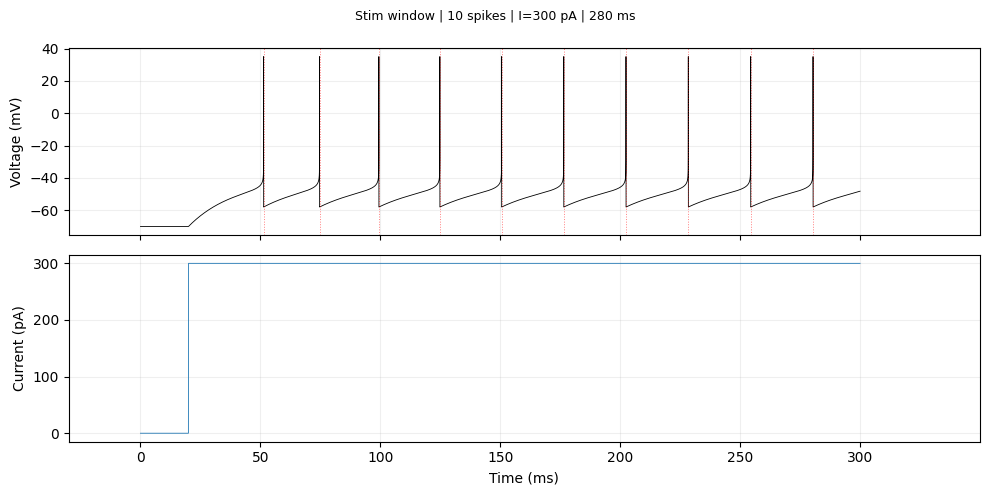

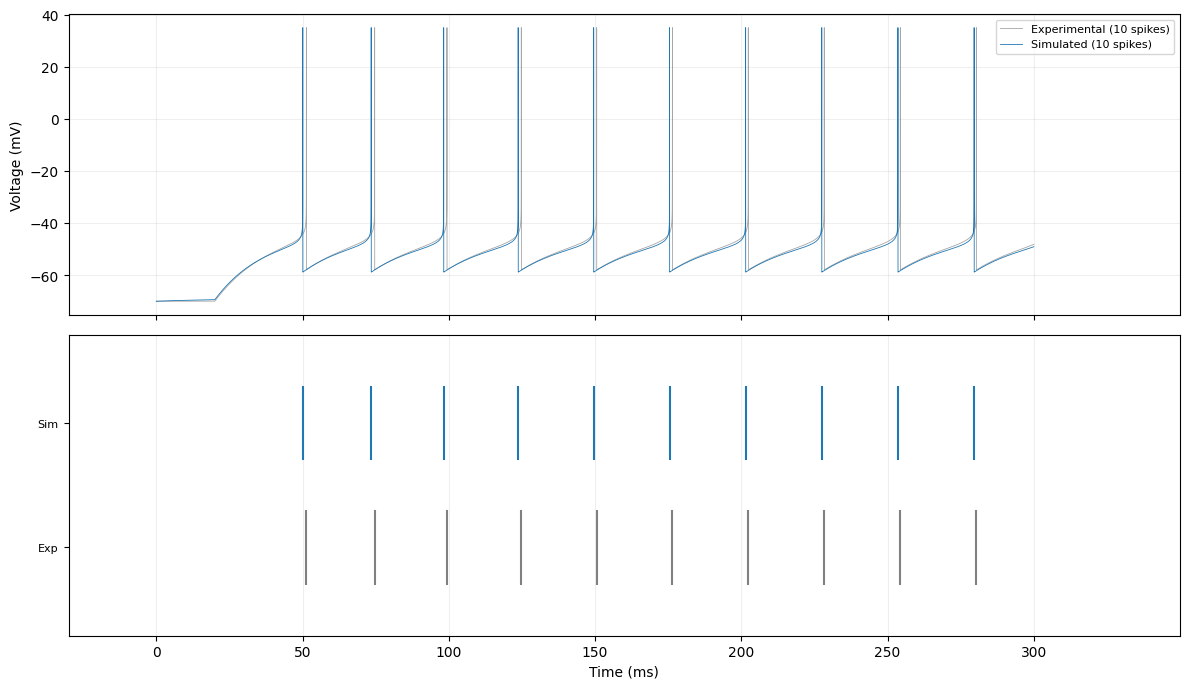

In [17]:
data = trace_stim1
trace_stim_window_plot(data)

# Carry over all previously fit parameters from stage 4
initial_params = params_after_s4.copy()

sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")
fit_comparison_plot(data, sim_init)
print(initial_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9


Training: optimizer=adam lr=0.01 epochs=150 surrogate=superspike slope=10.0 sigmoid_transform


Initial Soft-DTW loss: 5.1878


Epoch    0 | loss=5.187775 | grad_norm=7.62e+04 | C_m=200.7474, g_L=11.2522, E_L=-69.1503, v_T=-50.5599, delta_T=1.5419, v_reset=-58.9640, tau_w=30.4817, a=1.9605, b=0.0066
Epoch   10 | loss=33.740631 | grad_norm=2.79e+07 | C_m=201.9473, g_L=11.3189, E_L=-69.2925, v_T=-50.3404, delta_T=1.5618, v_reset=-58.7542, tau_w=29.5459, a=2.0363, b=0.0065
Epoch   20 | loss=33.108276 | grad_norm=4.20e+09 | C_m=202.6821, g_L=11.3601, E_L=-69.3834, v_T=-50.2022, delta_T=1.5747, v_reset=-58.6314, tau_w=28.9704, a=2.0829, b=0.0064
Epoch   30 | loss=33.624542 | grad_norm=3.49e+05 | C_m=203.6961, g_L=11.4173, E_L=-69.5141, v_T=-50.0076, delta_T=1.5932, v_reset=-58.3488, tau_w=28.1840, a=2.1480, b=0.0061
Epoch   40 | loss=32.205139 | grad_norm=8.48e+05 | C_m=204.0302, g_L=11.4356, E_L=-69.5574, v_T=-49.9440, delta_T=1.5995, v_reset=-58.2468, tau_w=27.9426, a=2.1675, b=0.0061
Epoch   50 | loss=33.750061 | grad_norm=4.42e+05 | C_m=203.7724, g_L=11.4185, E_L=-69.5176, v_T=-50.0009, delta_T=1.5948, v_reset=-


Stage 5 complete.
  Best loss:   2.9197
  Total time:  5.2 s
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 5: 10 spikes (target: 10)
Gamma = 1.000


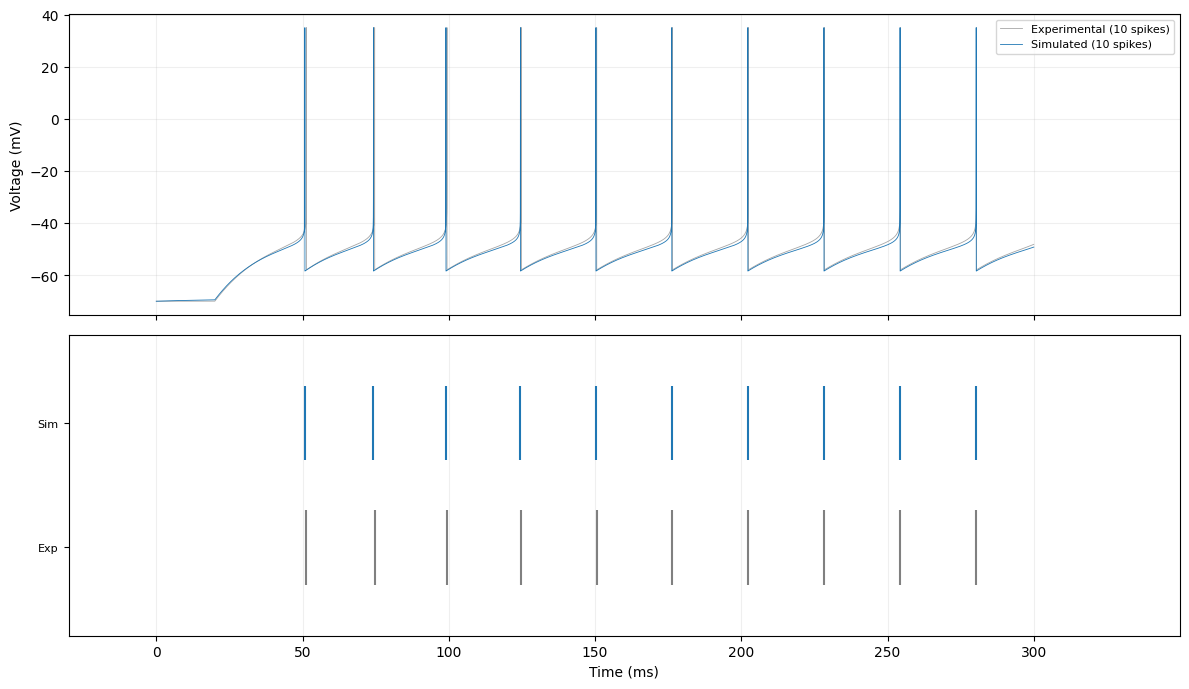

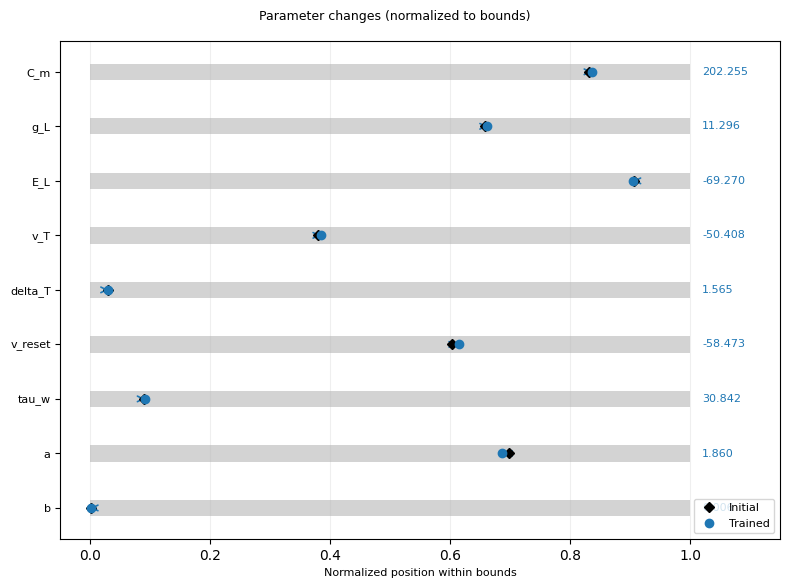

In [18]:
config_stage5 = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=150,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    print_every=10,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

cell5, data_stimuli5, t_max5, trainable_params5 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=config_stage5,
    trainable_params=TRAINABLE_STAGE5,
)

loss_fn_stage5 = make_soft_dtw_loss_fn(
    cell=cell5, data_stimuli=data_stimuli5, t_max=t_max5, dt_ms=data.dt_ms,
    exp_voltage=jnp.array(data.voltage), stim_end_index=data.stim_end_idx,
    window_size=50, stride=30, gamma=0.5, lambda_temp=10.0,
    spike_peak_mv=SPIKE_PEAK_MV,
)

print(f"Initial Soft-DTW loss: {float(loss_fn_stage5(trainable_params5)):.4f}")

result_stage5 = train(
    loss_fn=loss_fn_stage5,
    trainable_params=trainable_params5,
    config=config_stage5,
    initial_params=initial_params,
)

print(f"\nStage 5 complete.")
print(f"  Best loss:   {result_stage5.best_loss:.4f}")
print(f"  Total time:  {result_stage5.total_time:.1f} s")

# Evaluate stage 5
params_after_s5 = dict(initial_params)
params_after_s5.update(result_stage5.get_params_dict())

sim_stage5 = simulate_with_current_trace(
    params=params_after_s5,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 5: {sim_stage5.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage5.n_spikes > 0 and data.n_spikes > 0:
    cf_s5 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage5.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s5.gamma:.3f}")
else:
    cf_s5 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage5)
parameter_comparison_plot(result_stage5);

# Summary: all stages
Loss histories across the five-stage curriculum (the loss *type* differs between the
subthreshold MSE stages, the spiking Guarino stages, and the final soft-DTW stage, so
absolute values are not directly comparable — read each stage's trend, not cross-stage
levels). The final block scores the recovered parameters against the known ground truth.

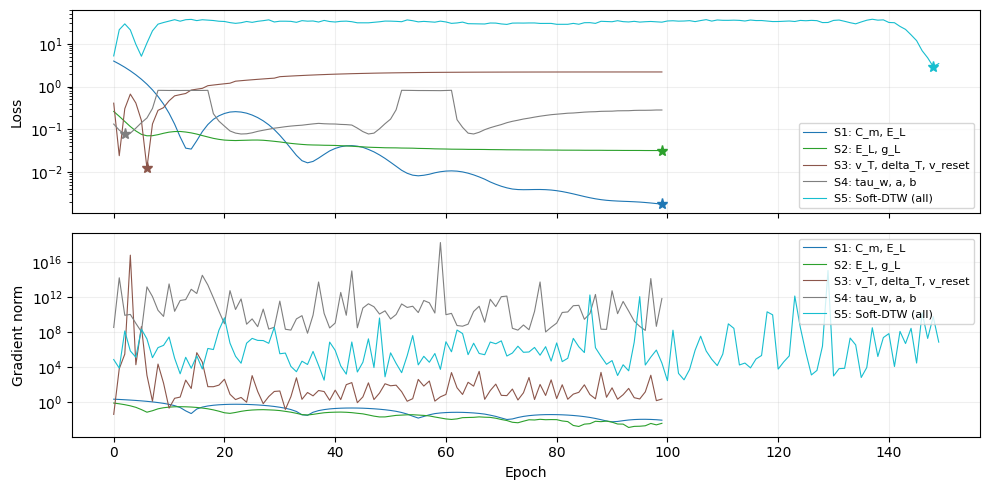

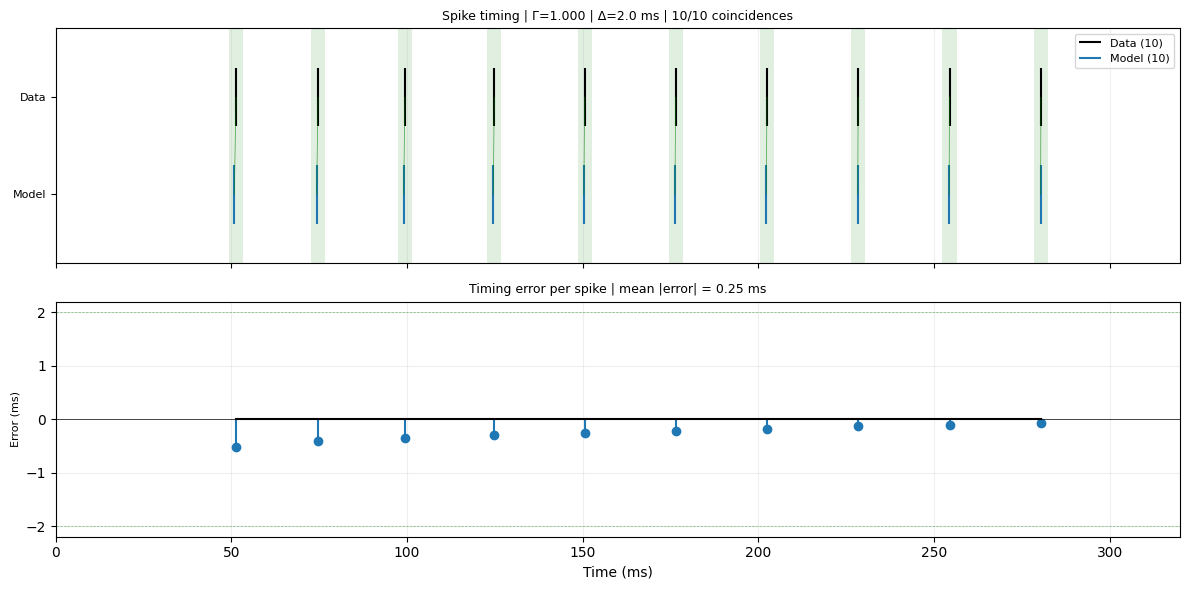

In [19]:
training_comparison_plot(
    [result_stage1, result_stage2, result_stage3, result_stage4, result_stage5],
    labels=[
        "S1: C_m, E_L",
        "S2: E_L, g_L",
        "S3: v_T, delta_T, v_reset",
        "S4: tau_w, a, b",
        "S5: Soft-DTW (all)",
    ],
    show_grad_norms=True,
)

if cf_s5 is not None:
    spike_timing_plot(trace_stim1, sim_stage5, cf_s5);

In [20]:
# --- Parameter recovery table: final vs ground truth ---
print("Parameter Recovery: Ground Truth vs Trained (final = after stage 5)")
print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Final':>12} {'Err (%)':>9}")
print("-" * 62)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    final = params_after_s5.get(k, init)
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(final - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {final:>12.3f} {err_pct:>8.1f}%")

Parameter Recovery: Ground Truth vs Trained (final = after stage 5)
Parameter    Ground Truth      Initial        Final   Err (%)
--------------------------------------------------------------
C_m               200.000      201.072      202.255      1.0%
E_L               -70.000      -69.188      -69.270      1.6%
a                   2.000        1.982        1.860      1.4%
b                   0.000        0.007        0.006      0.0%
delta_T             2.000        1.547        1.565      2.3%
g_L                10.000       11.270       11.296     16.2%
tau_w              30.000       30.223       30.842      0.3%
v_T               -50.000      -50.501      -50.408      1.6%
v_reset           -58.000      -58.880      -58.473      1.4%
